In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [4]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data[["charges"]]

X = pd.get_dummies(X , columns=["region"], drop_first=True,dtype=int)

X["sex"] = X["sex"].map({"female":1, "male":0})
X["smoker"] = X["smoker"].map({"yes":1 , "no": 0})

# interaction feature
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42)

In [6]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


# 1st way

In [7]:
lasso_model = Lasso(alpha=0.5)   # alpha controls bias-variance tradeoff
lasso_model.fit(X_train, y_train)  # train model with penalty
y_pred = lasso_model.predict(X_test)  # predict on unseen data
mse = mean_squared_error(y_test, y_pred)  # measure error
print("MSE: ", mse)


MSE:  20918648.889825605


# 2nd way

In [10]:
# 🎯 Step 2: Try different alpha values
alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)
    print(f"Alpha={a}, MSE={mse}")


Alpha=0.001, MSE=20922599.87103596
Alpha=0.1, MSE=20921803.698431376
Alpha=1, MSE=20914832.63508914
Alpha=2, MSE=20908106.779954515
Alpha=5, MSE=20890881.000633497
Alpha=10, MSE=20872844.794796683
Alpha=20, MSE=20877828.53237883
Alpha=50, MSE=21196929.8696089
Alpha=100, MSE=22423172.686023254


<Axes: >

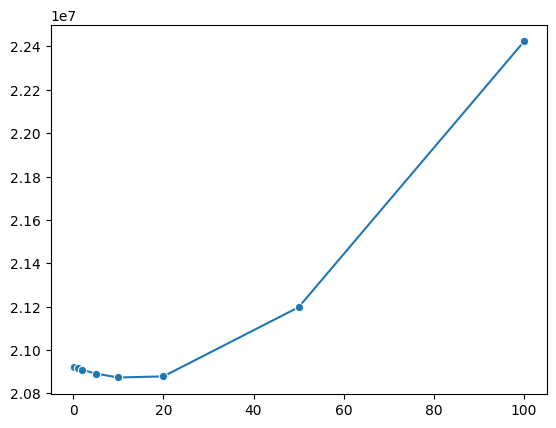

In [12]:
import seaborn as sns

sns.lineplot(x=alphas , y=mses , marker="o")

# ✅ Important:
# Whenever we use Lasso or Ridge regression, we should apply cross-validation
# to automatically select the best alpha (regularization strength).
# This balances bias and variance for optimal generalization.

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# Define alpha values to test
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

# Initialize LassoCV with cross-validation
lasso_cv = LassoCV(alphas=a,
                   cv=5, 
                   max_iter=1000, 
                   random_state=42)

lasso_cv.fit(X_train, y_train)

# Print best alpha chosen by CV
print("Best alpha:", lasso_cv.alpha_)

# Predict on test data
y_pred = lasso_cv.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


Best alpha: 0.001
MSE: 20922599.87103596
R2: 0.8652317499151699


C:\Users\Akash\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:1656: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
